Gradient Descent is an algorithm that finds the local extrema of a function. This is applicable to machine learning, because we want to find the optimal parameters that minimize our loss function. In machine learning, loss functions quantify the amount of error between the predicted values from a machine learning model and the actual expected values. In this notebook, we will perform linear regression by using gradient descent to find the optimal slope and y-intercept.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

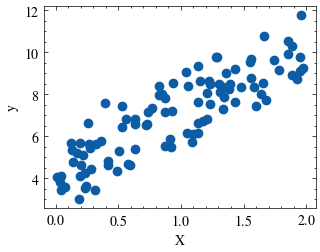

In [4]:
# Parameters
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()


Define the Cost Function
Use Mean Squared Error (MSE) to measure how far the predictions are from the actual values. 

𝑀𝑆𝐸=1𝑛∑𝑖=1𝑛(𝑦𝑖−𝑦̂ )2=1𝑛∑𝑖=1𝑛(𝑦𝑖−(𝑤𝑥𝑖+𝑏))2


Implement Gradient Descent 
This is the core loop where you update your weights based on the slope of the error

In [27]:
m = 0.01# Initial weight
b = 0 # Initial bias
lr = 0.1 # Learning rate
n = len(X)

for i in range(1000):
    y_pred = m * X + b
    
    # Calculate gradients
    dm = (-2/n) * sum(X * (y - y_pred))
    db = (-2/n) * sum(y - y_pred)
    # Update parameters
    m = m - lr * dm
    b = b - lr * db

print(f"Final m: {m[0]}, Final b: {b[0]}")


Final m: 2.968467510701028, Final b: 4.222151077447219


Visualize the result
Plot your learned line against the original data points to verify the fit.

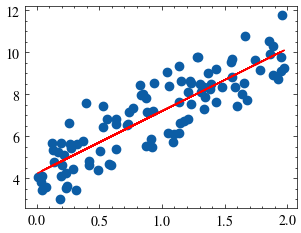

In [28]:
plt.scatter(X, y)
plt.plot(X, m*X + b, color='red') # The regression line
plt.show()

Things to monitor
1. Learning Rate (lr)
Set to 0.001 (Too Low): The model becomes "lazy." It takes tiny steps toward the solution. You will likely need tens of thousands of iterations to reach the best fit.
Set to 1.0 (Too High): The model overshoots the "valley" (minimum error). It bounces back and forth, often getting further away from the answer until the numbers become so large they crash the code (NaN errors).


2. Iterations
10 Iterations: The line will likely look flat or barely tilted. The algorithm hasn't had enough "time" to adjust the weights from their starting zeros to the actual data trend.
1000 Iterations: This is usually enough for a simple linear model to "converge." The line will snap perfectly onto the data points and stop changing significantly.


3. Starting Point (m and b)
Small numbers (0, 0): A standard, "safe" starting point.
Large numbers (100, 100): The first few predictions will be wildly wrong, creating massive error values.
The Result: As long as your learning rate is small enough, the algorithm will still eventually find the right answer. It just has a much longer "walk" down the hill to get there.

If you use a high starting point and a high learning rate together, your model will likely diverge and fail immediately.

In Stochastic Gradient Descent (SGD), instead of looking at the entire dataset to take one step, the algorithm picks one random data point at each step.

Why use SGD?
Speed: It’s much faster for massive datasets.
Memory: You don't need to load the whole dataset into RAM.
Escape: The "noise" helps the model jump out of local minima (bad solutions). 

In [30]:
#Replace your Step 4 loop with this "shuffled" version:

m = 0
b = 0
lr = 0.01
epochs = 50 # Number of passes through the whole dataset
n = len(X)

for epoch in range(epochs):
    # Shuffle data at the start of each epoch
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    for i in range(n):
        # Pick ONE random sample
        xi = X_shuffled[i:i+1]
        yi = y_shuffled[i:i+1]
        
        # Calculate prediction for just this point
        y_pred = m * xi + b
        
        # Gradients for just this point
        dm = -2 * xi * (yi - y_pred)
        db = -2 * (yi - y_pred)
        
        # Update weights immediately
        m = m - lr * dm
        b = b - lr * db


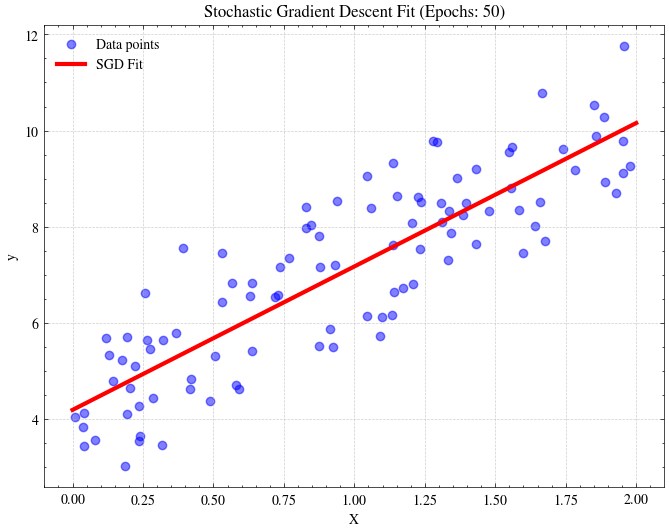

In [31]:
# 1. Clear the figure
plt.figure(figsize=(8, 6))

# 2. Plot the original data points
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')

# 3. Create predictions across the X range
# Note: We flatten m and b values if they are arrays
X_line = np.array([[0], [2]])
y_line = m * X_line + b

# 4. Plot the regression line
plt.plot(X_line, y_line, color='red', linewidth=3, label='SGD Fit')

# 5. Labeling
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Stochastic Gradient Descent Fit (Epochs: {epochs})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
